In [1]:
# =========================================================
# CONFIGURAÇÃO INICIAL DO NOTEBOOK
# =========================================================

%reload_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd

sys.path.append(os.path.abspath(".."))

from src.tratamento_dados import TratamentoDados

In [2]:
# =========================================================
# CARREGANDO O DATASET
# =========================================================

caminho_arquivo = "../data/desafio_nps_fase_1.csv"

df = pd.read_csv(caminho_arquivo)

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [3]:
# =========================================================
# TRATAMENTO INICIAL DOS DADOS
# =========================================================

# Instancia a classe responsável pelo tratamento da base
tratamento = TratamentoDados(df)

# Exibe diagnóstico inicial:
# quantidade de linhas, colunas, duplicados e valores nulos
tratamento.diagnostico_inicial()

# Remove registros duplicados da base
tratamento.remover_duplicados()

# Trata valores nulos:
# - colunas numéricas → mediana
# - colunas categóricas → moda
tratamento.tratar_nulos_simples()

# Remove colunas identificadoras que não devem participar
# do treinamento do modelo preditivo, pois representam apenas
# IDs de controle e não variáveis explicativas do problema
tratamento.remover_colunas([
    "customer_id",
    "order_id"
])

# Cria a variável alvo categórica para classificação NPS:
# 0-6 → Detrator
# 7-8 → Neutro
# 9-10 → Promotor
tratamento.criar_classe_nps()

# Cria a classificação de satisfação do cliente (CSAT):
# 0-2   → Muito insatisfeito
# 2-4   → Insatisfeito
# 4-6   → Indiferente
# 6-8   → Satisfeito
# 8-10  → Muito satisfeito
tratamento.criar_classe_csat()

# Retorna o dataframe final após todas as transformações
df_tratado = tratamento.obter_dataframe()

# Visualiza as primeiras linhas da base tratada
df_tratado.head()

DIAGNÓSTICO INICIAL
Linhas: 2500
Colunas: 19
Duplicados: 0

Valores nulos por coluna:
customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64
REMOÇÃO DE DUPLICADOS
Linhas antes: 2500
Linhas depois: 2500
Duplicados removidos: 0
TRATAMENTO DE NULOS
Nulos restantes:
Series([], dtype: int64)
REMOÇÃO DE COLUNAS
Colunas removidas: ['customer_id', 'order_id']
CRIAÇÃO DA CLASSE NPS
classe_nps
Detrator    1851
Neutro       448
Promotor     201
Name: count, dt

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,classe_nps,classe_csat
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,Neutro,Satisfeito
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,Detrator,Muito insatisfeito
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,Detrator,Muito insatisfeito
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,Detrator,Muito insatisfeito
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,Neutro,Satisfeito


In [4]:
# =========================================================
# PREPARAÇÃO DA BASE PARA MODELAGEM
# =========================================================

# Define quais colunas não devem participar do modelo
# pois podem causar vazamento de informação (data leakage)
# ou representam variáveis derivadas da própria variável alvo
colunas_remover_modelo = [
    "nps_score",
    "csat_internal_score",
    "classe_csat"
]

# Prepara a base:
# X = variáveis explicativas
# y = variável alvo (classe_nps)
X, y = tratamento.preparar_base_modelagem(
    coluna_alvo="classe_nps",
    colunas_remover=colunas_remover_modelo,
    drop_first=True,
    mostrar_saida=True
)

# Visualiza as primeiras linhas da base pronta para modelagem
print(X.head())

# Visualiza a variável alvo
print(y.head())

PREPARAÇÃO DA BASE PARA MODELAGEM
Variável alvo: classe_nps
Colunas removidas: ['nps_score', 'csat_internal_score', 'classe_csat']
Shape de X: (2500, 18)
Shape de y: (2500,)

Primeiras colunas de X:
['customer_age', 'customer_tenure_months', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'repeat_purchase_30d', 'complaints_count', 'customer_region_Nordeste', 'customer_region_Norte', 'customer_region_Sudeste', 'customer_region_Sul']
   customer_age  customer_tenure_months  order_value  items_quantity  \
0            63                      14       139.73               4   
1            20                       1       458.95               2   
2            46                     111       507.06               5   
3            52                     117       302.19               2   
4            56                      50  

In [5]:
# =========================================================
# PREPARAÇÃO DA BASE PARA MODELAGEM
# =========================================================

# Define quais colunas não devem participar do modelo
# pois podem causar vazamento de informação (data leakage)
# ou representam variáveis derivadas da própria variável alvo
colunas_remover_modelo = [
    "nps_score",
    "csat_internal_score",
    "classe_csat"
]

# Prepara a base:
# X = variáveis explicativas
# y = variável alvo (classe_nps)
X, y = tratamento.preparar_base_modelagem(
    coluna_alvo="classe_nps",
    colunas_remover=colunas_remover_modelo,
    drop_first=True,
    mostrar_saida=True
)

# Visualiza as primeiras linhas da base pronta para modelagem
print(X.head())

# Visualiza a variável alvo
print(y.head())

PREPARAÇÃO DA BASE PARA MODELAGEM
Variável alvo: classe_nps
Colunas removidas: ['nps_score', 'csat_internal_score', 'classe_csat']
Shape de X: (2500, 18)
Shape de y: (2500,)

Primeiras colunas de X:
['customer_age', 'customer_tenure_months', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'repeat_purchase_30d', 'complaints_count', 'customer_region_Nordeste', 'customer_region_Norte', 'customer_region_Sudeste', 'customer_region_Sul']
   customer_age  customer_tenure_months  order_value  items_quantity  \
0            63                      14       139.73               4   
1            20                       1       458.95               2   
2            46                     111       507.06               5   
3            52                     117       302.19               2   
4            56                      50  

In [6]:
# =========================================================
# MODELAGEM PREDITIVA RANDOM FOREST
# O Random Forest permite antecipar o comportamento do cliente, transformando sinais operacionais em decisões preventivas de experiência.
# =========================================================

from src.analise_preditiva import AnalisePreditiva

# Instancia a classe de análise preditiva usando a base preparada
preditiva = AnalisePreditiva(X, y)

# Divide a base em treino e teste
preditiva.dividir_treino_teste(
    test_size=0.2,
    random_state=42,
    stratify=True
)

# Treina o primeiro modelo: Random Forest
modelo_rf = preditiva.treinar_random_forest()


# =========================================================
# VISUALIZANDO AS PREVISÕES DO MODELO
# =========================================================

# Retorna os resultados consolidados
resultados_modelos = preditiva.obter_resultados()

resultados_modelos


DIVISÃO TREINO E TESTE
X_train: (2000, 18)
X_test:  (500, 18)
y_train: (2000,)
y_test:  (500,)
MODELO — RANDOM FOREST
Accuracy: 0.8560
Precision Macro: 0.8552
Recall Macro: 0.7530
F1 Macro: 0.7623

Relatório de classificação:
              precision    recall  f1-score   support

    Detrator       0.85      0.98      0.91       370
      Neutro       0.78      0.28      0.41        90
    Promotor       0.93      1.00      0.96        40

    accuracy                           0.86       500
   macro avg       0.86      0.75      0.76       500
weighted avg       0.85      0.86      0.83       500



,modelo,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Random Forest,0.856,0.8552,0.752953,0.7623,0.847091,0.856,0.826653


ANÁLISE DAS PREVISÕES DO MODELO
Modelo analisado: Árvore de Decisão

Amostra de previsões:
        real  previsto  acertou
0     Neutro  Detrator    False
1   Detrator  Detrator     True
2   Detrator  Detrator     True
3   Detrator  Detrator     True
4   Detrator  Detrator     True
5     Neutro    Neutro     True
6   Detrator  Detrator     True
7   Detrator    Neutro    False
8   Detrator  Detrator     True
9   Detrator  Detrator     True
10    Neutro  Detrator    False
11    Neutro    Neutro     True
12  Detrator  Detrator     True
13  Detrator  Detrator     True
14    Neutro  Detrator    False
15  Promotor  Promotor     True
16  Detrator  Detrator     True
17  Detrator  Detrator     True
18  Detrator  Detrator     True
19  Detrator  Detrator     True

Resumo da acurácia manual:
Total de registros testados: 500
Total de acertos: 386
Acurácia manual: 0.7720

Matriz de confusão:
               Previsto Detrator  Previsto Neutro  Previsto Promotor
Real Detrator                315        

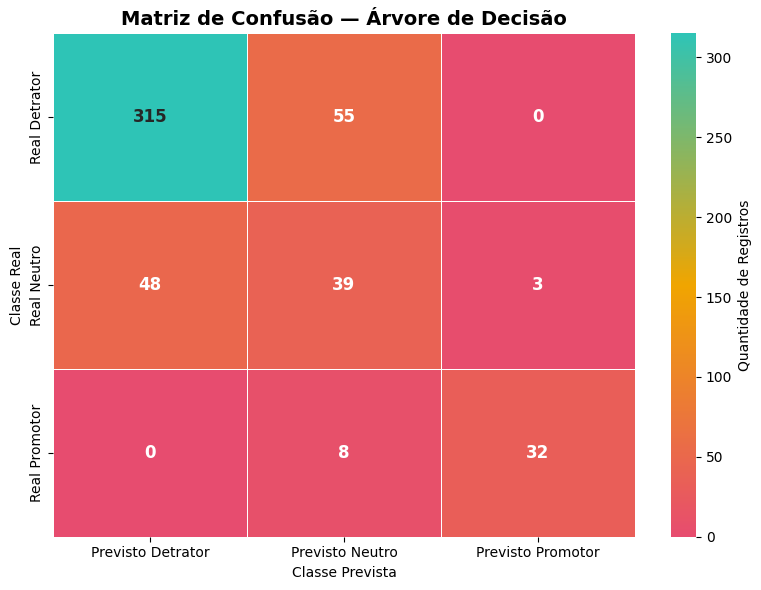

MATRIZ DE CONFUSÃO EXPORTADA
Arquivo salvo em: ../images/matriz_confusao_random_forest.png


,Previsto Detrator,Previsto Neutro,Previsto Promotor
Real Detrator,315,55,0
Real Neutro,48,39,3
Real Promotor,0,8,32


In [9]:
analise_previsoes = preditiva.analisar_previsoes(
    mostrar_saida=True,
    qtd_exibir=20
)

analise_previsoes["comparacao_previsoes"].head(20)

analise_previsoes["matriz_confusao"]

analise_previsoes["relatorio_classificacao"]

analise_previsoes["accuracy_manual"]

preditiva.exportar_matriz_confusao(
    salvar_em="../images/matriz_confusao_random_forest.png",
    mostrar_saida=True
) 

In [8]:
# ============================================================
# TREINAMENTO DOS 4 MODELOS RESTANTES + COMPARAÇÃO DOS 6
# ============================================================

# 3. SVM
preditiva.treinar_svm()
preditiva.analisar_previsoes()


# 4. SVM + StandardScaler
preditiva.treinar_svm_com_scaler()
preditiva.analisar_previsoes()


# 5. Extra Trees
preditiva.treinar_extra_trees()
preditiva.analisar_previsoes()


# 6. Árvore de Decisão
preditiva.treinar_arvore_decisao()
preditiva.analisar_previsoes()



# ============================================================
# COMPARAÇÃO FINAL DOS 6 MODELOS
# ============================================================

comparacao_modelos = preditiva.obter_resultados()

comparacao_modelos = comparacao_modelos.sort_values(
    by="f1_macro",
    ascending=False
)

print("=" * 70)
print("COMPARAÇÃO FINAL DOS MODELOS")
print("=" * 70)

display(comparacao_modelos)

MODELO — SVM
Accuracy: 0.4140
Precision Macro: 0.3290
Recall Macro: 0.3068
F1 Macro: 0.2938

Relatório de classificação:
              precision    recall  f1-score   support

    Detrator       0.75      0.47      0.58       370
      Neutro       0.18      0.30      0.23        90
    Promotor       0.05      0.15      0.07        40

    accuracy                           0.41       500
   macro avg       0.33      0.31      0.29       500
weighted avg       0.59      0.41      0.48       500

ANÁLISE DAS PREVISÕES DO MODELO
Modelo analisado: SVM

Amostra de previsões:
        real  previsto  acertou
0     Neutro  Promotor    False
1   Detrator  Detrator     True
2   Detrator  Promotor    False
3   Detrator    Neutro    False
4   Detrator  Detrator     True
5     Neutro  Detrator    False
6   Detrator  Detrator     True
7   Detrator  Promotor    False
8   Detrator  Detrator     True
9   Detrator  Detrator     True
10    Neutro  Detrator    False
11    Neutro  Detrator    False
12  D

,modelo,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
2,SVM + StandardScaler,0.798,0.773868,0.838939,0.794590,0.845878,0.798,0.812693
0,Random Forest,0.856,0.855200,0.752953,0.762300,0.847091,0.856,0.826653
3,Extra Trees,0.854,0.852180,0.749249,0.757537,0.844337,0.854,0.823438
4,Árvore de Decisão,0.772,0.721469,0.694895,0.706355,0.784115,0.772,0.777408
1,SVM,0.414,0.328986,0.306757,0.293823,0.594593,0.414,0.475562
